In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier

In [34]:
loan = pd.read_csv("datasets/loan_approval_data.csv")
loan_df = loan.copy()

In [35]:
loan_df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [36]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [37]:
loan_df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Removing unnecessary columns

In [38]:
loan_df = loan_df.drop(columns=["Applicant_ID"], axis=1)

# Removing Duplicated rows

In [39]:
loan_df.duplicated().sum()
# There are no duplicated rows 

np.int64(0)

# Removing missing output rows

In [40]:
loan_df = loan_df.dropna(subset=["Loan_Approved"])

# Splitting Data

In [41]:
X = loan_df.drop("Loan_Approved", axis=1)
y = loan_df["Loan_Approved"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

# Filling missing values

In [43]:
# For input columns
X_train_numeric = X_train.select_dtypes(include=["number"])
X_train_string = X_train.select_dtypes(exclude=["number"])
X_test_numeric = X_test.select_dtypes(include=["number"])
X_test_string = X_test.select_dtypes(exclude=["number"])

In [44]:
numeric_imputer = SimpleImputer(strategy="mean").set_output(transform="pandas")
X_train_numeric = numeric_imputer.fit_transform(X_train_numeric)
X_test_numeric = numeric_imputer.transform(X_test_numeric)

In [45]:
string_imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
X_train_string = string_imputer.fit_transform(X_train_string)
X_test_string = string_imputer.transform(X_test_string)

In [46]:
# we want to preserve the original order of columns
columns = X_train.columns
X_train = pd.concat([X_train_string, X_train_numeric], axis=1)
X_test = pd.concat([X_test_string, X_test_numeric], axis=1)

# EDA - Exploratory Data Analysis

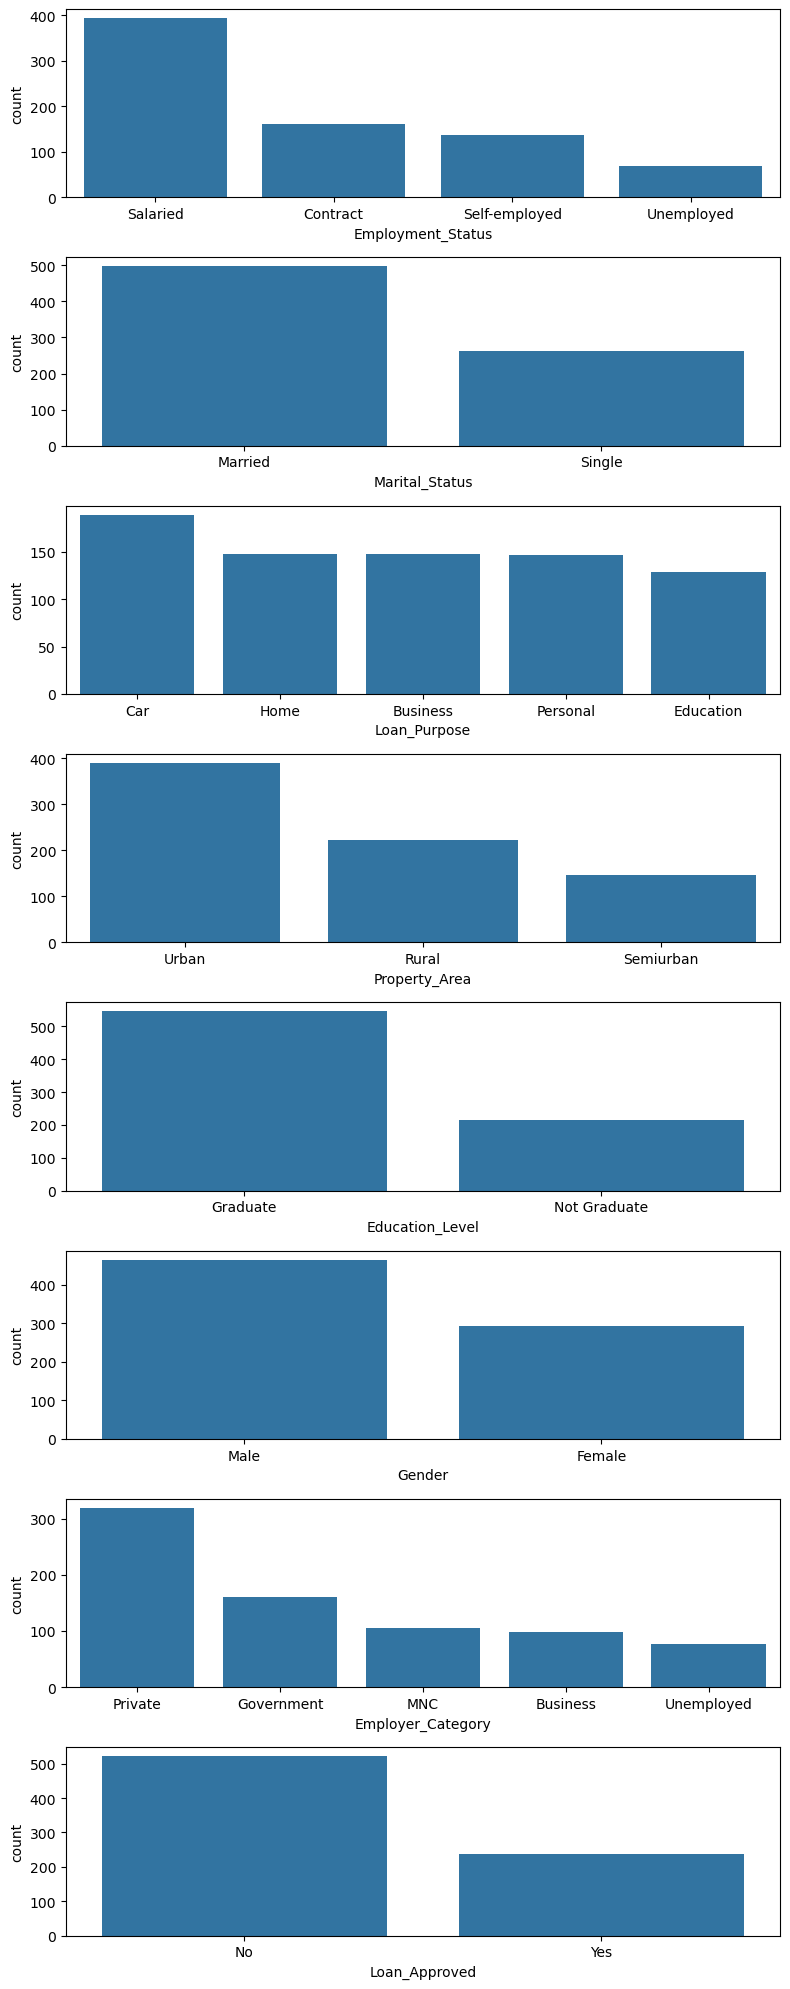

In [47]:
# Value counts in categorical features
fig, axes = plt.subplots(len(X_train_string.columns) + 1, 1, figsize=(8, 20))
axes = axes.flatten()

for i in range(0, len(X_train_string.columns)):
    column = X_train_string.iloc[:, i]
    sns.barplot(column.value_counts(), ax=axes[i])
sns.barplot(y_train.value_counts(), ax=axes[7])

plt.tight_layout()

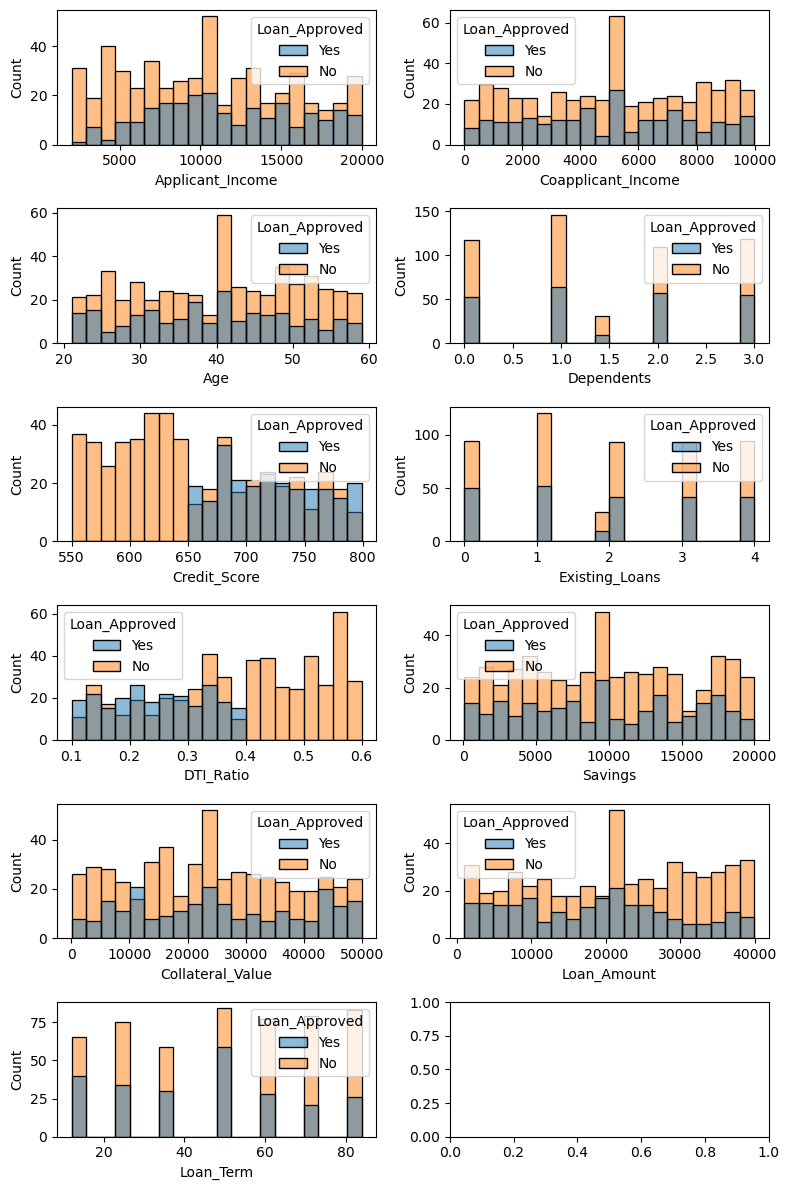

In [48]:
# Analyzing average & outliers for numeric features
fig, axes = plt.subplots(6, 2, figsize=(8, 12))
axes = axes.flatten()

for i in range(0, len(X_train_numeric.columns)):
    sns.histplot(x=X_train_numeric.iloc[:, i], bins=20, hue=y_train, ax=axes[i])
plt.tight_layout()

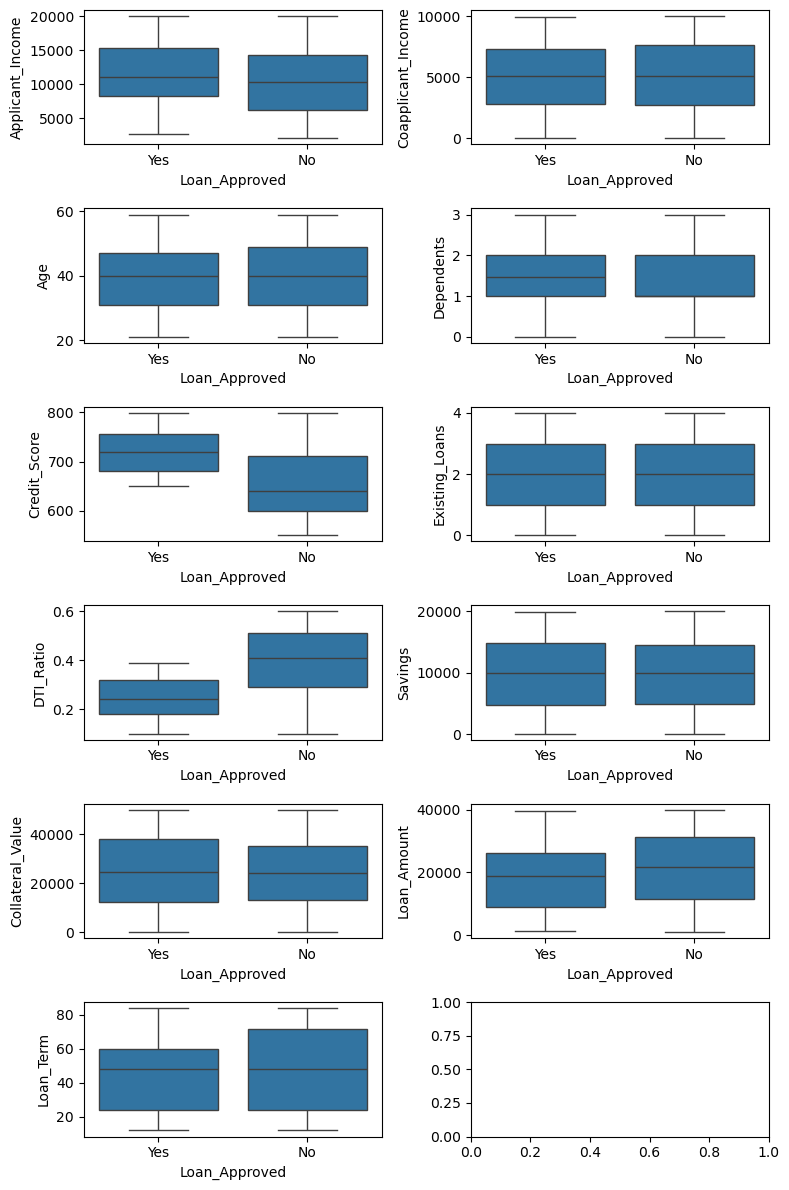

In [49]:
fig, axes = plt.subplots(6, 2, figsize=(8, 12))
axes = axes.flatten()

for i in range(0, len(X_train_numeric.columns)):
    sns.boxplot(x=y_train, y=X_train_numeric.iloc[:, i], ax=axes[i])
plt.tight_layout()

# Feature engineering

## Encoding

In [50]:
# label encoding
le = LabelEncoder()
X_train["Gender"] = le.fit_transform(X_train["Gender"])
X_test["Gender"] = le.transform(X_test["Gender"])

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [51]:
# Ordinal encoding
oe = OrdinalEncoder(categories=[["Not Graduate", "Graduate"], ["Single", "Married"]])
X_train[["Education_Level", "Marital_Status"]] = oe.fit_transform(X_train[["Education_Level", "Marital_Status"]])
X_test[["Education_Level", "Marital_Status"]] = oe.transform(X_test[["Education_Level", "Marital_Status"]])

In [52]:
# One hot encoding 
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first").set_output(transform="pandas")
columns = ["Employment_Status", "Loan_Purpose","Property_Area", "Employer_Category"]

encoded = ohe.fit_transform(X_train[columns])
X_train = pd.concat([X_train, encoded], axis=1).drop(columns=columns, axis=1)

encoded = ohe.transform(X_test[columns])
X_test = pd.concat([X_test, encoded], axis=1).drop(columns=columns, axis=1)

## Correlation Heatmap

In [53]:
corr_matrix = pd.concat([X_train, pd.DataFrame(y_train, columns=["Loan_Approved"])], axis=1).corr()
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Existing_Loans                     0.091008
Employment_Status_Salaried         0.067448
Property_Area_Urban                0.056252
Gender                             0.054092
Employer_Category_Unemployed       0.053924
DTI_Ratio                          0.047841
Loan_Purpose_Home                  0.033356
Coapplicant_Income                 0.028966
Age                                0.025359
Employer_Category_Government       0.024117
Savings                            0.019468
Collateral_Value                   0.017582
Loan_Term                          0.012242
Loan_Purpose_Education             0.007487
Employment_Status_Self-employed   -0.006238
Loan_Amount                       -0.007119
Loan_Purpose_Car                  -0.009422
Employment_Status_Unemployed      -0.013929
Property_Area_Semiurban           -0.016286
Loan_Purpose_Personal             -0.029101
Employer_Category_MNC             -0.031555
Employer_Category_Private       

<Axes: >

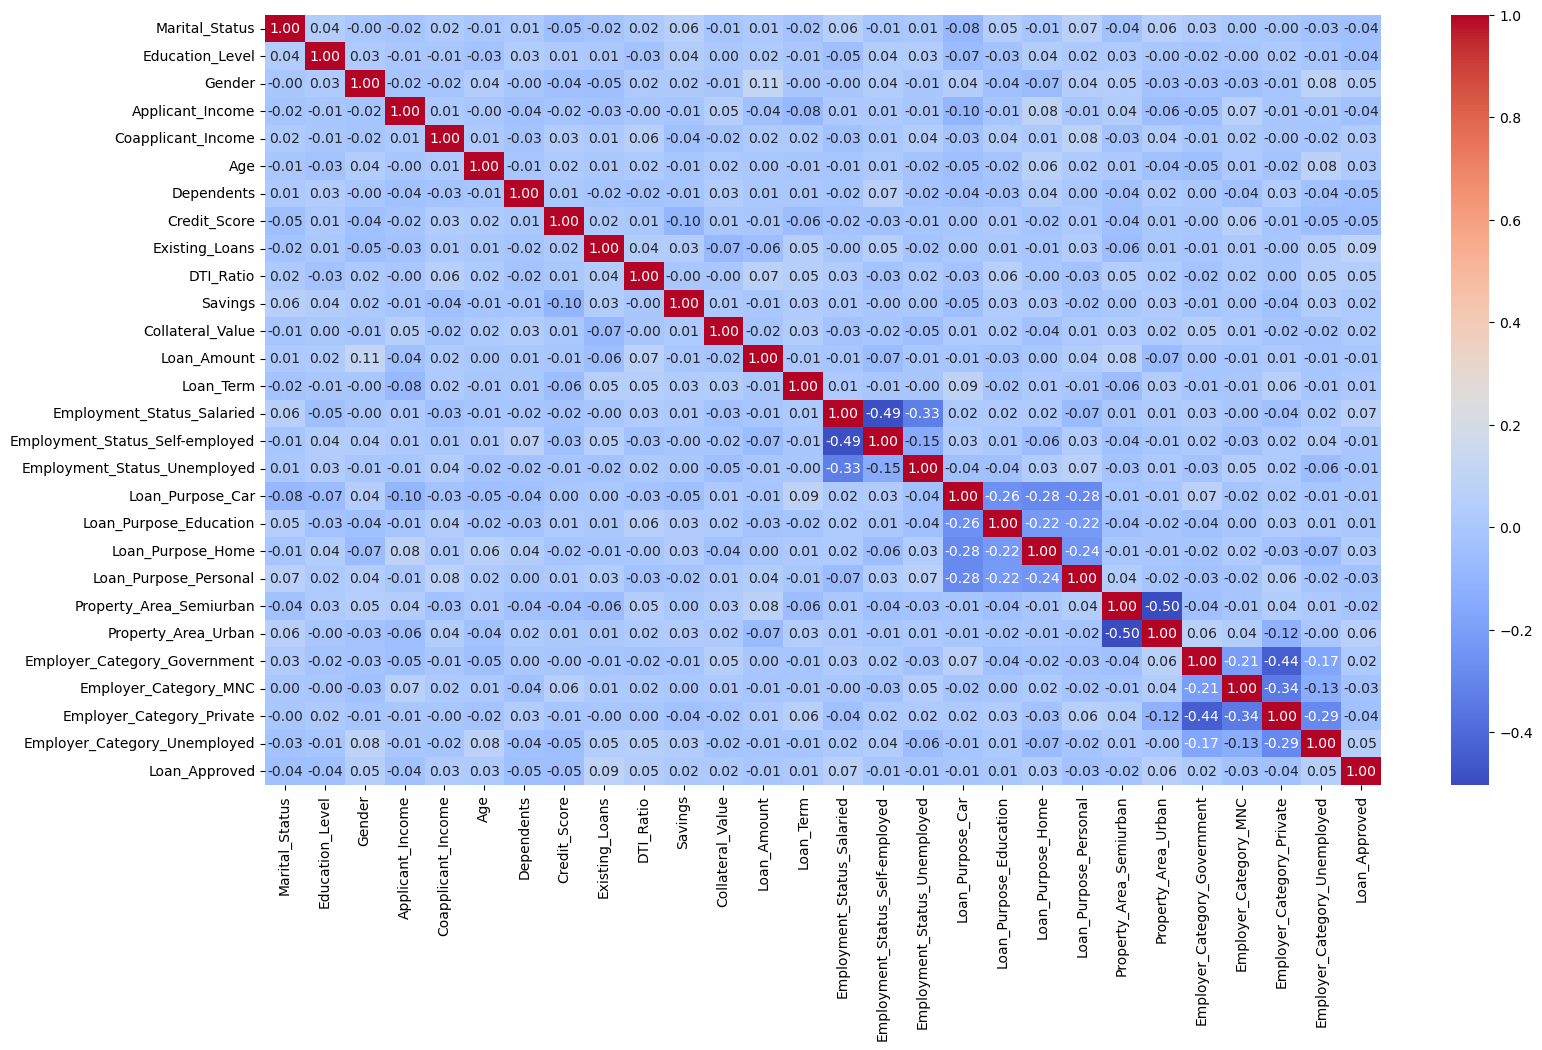

In [54]:
plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
# It shows data is not very linearly correlated implying linear models won't perform very good

## Deriving features

In [55]:
# These features have linear relation with output so increasing their impact
X_train["DTI_Ratio"] = X_train["DTI_Ratio"] ** 2
X_test["DTI_Ratio"] = X_test["DTI_Ratio"] ** 2
X_train["Age"] = X_train["Age"] ** 2
X_test["Age"] = X_test["Age"] ** 2

## Feature scaling

In [56]:
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model training and evaluation

## Logistic regression

In [57]:

lr_model = LogisticRegression(max_iter=50000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Logistic Regression:
Accuracy: 0.8894736842105263
Precision: 0.8545454545454545
Recall: 0.7833333333333333
F1: 0.8173913043478261
[[122   8]
 [ 13  47]]


## kNN Classifier


In [58]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
cm = confusion_matrix(y_test, y_pred_knn)

print("kNN Classifier:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

kNN Classifier:
Accuracy: 0.7736842105263158
Precision: 0.6888888888888889
Recall: 0.5166666666666667
F1: 0.5904761904761905
[[116  14]
 [ 29  31]]


## Naive Bayes


In [59]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
cm = confusion_matrix(y_test, y_pred_nb)

print("Naive Bayes:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Naive Bayes:
Accuracy: 0.868421052631579
Precision: 0.8181818181818182
Recall: 0.75
F1: 0.782608695652174
[[120  10]
 [ 15  45]]


## Decision Tree

In [60]:
dtc_model = DecisionTreeClassifier(
    min_samples_split=10,
    random_state=42
)
dtc_model.fit(X_train, y_train)

y_pred_nb = dtc_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
cm = confusion_matrix(y_test, y_pred_nb)

print("Decision tree:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Decision tree:
Accuracy: 0.9578947368421052
Precision: 0.90625
Recall: 0.9666666666666667
F1: 0.9354838709677419
[[124   6]
 [  2  58]]


# XGBoost

In [61]:
xgbc_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=4
)
xgbc_model.fit(X_train, y_train)

y_pred_nb = xgbc_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
cm = confusion_matrix(y_test, y_pred_nb)

print("XGBC:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

XGBC:
Accuracy: 0.968421052631579
Precision: 0.9354838709677419
Recall: 0.9666666666666667
F1: 0.9508196721311475
[[126   4]
 [  2  58]]


Individually, XGBoosting performed best for given dataset.

## Ensemble learning - stacking

In [64]:
sc_model = StackingClassifier(
    estimators=[
        ("dtc", dtc_model),
        ("xgbc", xgbc_model),
    ],
    cv=10,
)
sc_model.fit(X_train, y_train)

y_pred_nb = sc_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)
cm = confusion_matrix(y_test, y_pred_nb)

print("Stacking:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print(cm)

Stacking:
Accuracy: 0.968421052631579
Precision: 0.9354838709677419
Recall: 0.9666666666666667
F1: 0.9508196721311475
[[126   4]
 [  2  58]]


Same performance as XGBoost